# Exploratory Data Analysis — CMS DE-SynPUF (OMOP CDM)

**Project context:** member-level utilization-risk prediction (Low / Medium / High) — see `Team1_RFC.docx`.

**Dataset.** The [CMS DE-SynPUF](https://www.cms.gov/data-research/statistics-trends-reports/medicare-claims-synthetic-public-use-files) (Designated Entity Synthetic Public Use File) is a synthetic Medicare claims dataset published by CMS. It preserves the structure and statistical properties of real Medicare fee-for-service claims without containing any real beneficiary data. We work with the OMOP CDM v5.x-conformant release (OHDSI), which maps the raw claims into standard tables (`person`, `visit_occurrence`, `condition_occurrence`, `drug_exposure`, `drug_era`, `procedure_occurrence`, `measurement`, `observation`, `observation_period`, `death`, ...). Data were obtained as plain CSV exports under `data/raw/synpuf1k/` (1,000 persons, primary EDA target) and `data/raw/synpuf100k/` (100,000 persons, full working set).

**Key limitations to keep in mind.**
- There is **no concept/vocabulary table**, so all categorical breakdowns use `*_source_value` columns (e.g. `condition_source_value` carries raw ICD-9 codes) and hard-coded OMOP concept IDs (9201 = Inpatient Visit, 9202 = Outpatient Visit, 9203 = Emergency Room Visit; 8507/8532 = Male/Female).
- ICD-9 codes appear **without dots** (e.g. `4280` for 428.0); chronic-condition matching below uses 3-digit prefix ranges.
- The data are synthetic; some prevalences (e.g. cancer) are unrealistically high because diagnoses are duplicated across carriers/institutional claim lines.

**Structure of this notebook.**
1. Setup, loading, and validation (1k sample).
2. Table inventory & record counts vs. classic DE-SynPUF expectations.
3. Per-table analysis: person, observation_period, visit_occurrence, condition_occurrence, drug_exposure / drug_era, procedure / measurement / observation, death.
4. Missingness profile.
5. 100k headline validation (streaming `usecols` reads — the full 100k set is ~4–6 GB in memory and is never loaded at once).
6. Summary.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from load_synpuf import load_dataset, validate_dataset, EXPECTED_ROWS

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

SAMPLE = "1k"
tables = load_dataset(SAMPLE)
person = tables["person"]
print(f"Loaded {len(tables)} tables from data/raw/synpuf{SAMPLE}/")
report = validate_dataset(tables, SAMPLE)
assert report["passed"].all(), report[~report["passed"]]
report

Loaded 15 tables from data/raw/synpuf1k/


,check,table,passed,detail
0,row_count>0,care_site,True,"rows=20,748"
1,row_count>0,condition_era,True,"rows=121,386"
2,row_count>0,condition_occurrence,True,"rows=160,322"
3,row_count>0,death,True,rows=45
4,row_count>0,device_exposure,True,"rows=1,622"
5,row_count>0,drug_era,True,"rows=52,714"
6,row_count>0,drug_exposure,True,"rows=49,542"
7,row_count>0,location,True,rows=626
8,row_count>0,measurement,True,"rows=2,858"
9,row_count>0,observation,True,"rows=13,481"


## 1. Table inventory & record counts

The 1k sample should contain ~1,000 persons with roughly 47 visits and ~160 condition rows per person — the signature per-capita densities of DE-SynPUF.

In [2]:
N_PERSONS = len(person)
inv = (
    pd.DataFrame({"table": list(tables), "rows": [len(t) for t in tables.values()]})
    .sort_values("rows", ascending=False)
    .set_index("table")
)
inv["rows_per_person"] = (inv["rows"] / N_PERSONS).round(1)

# Attach the loader's hard expected ranges where defined.
def expectation(table):
    rng = EXPECTED_ROWS.get(SAMPLE, {}).get(table)
    return f"[{rng[0]:,}, {rng[1]:,}]" if rng else "—"

inv["expected_rows"] = [expectation(t) for t in inv.index]
inv

,rows,rows_per_person,expected_rows
table,,,
condition_occurrence,160322,160.3,"[150,000, 175,000]"
condition_era,121386,121.4,—
procedure_occurrence,62189,62.2,—
drug_era,52714,52.7,—
drug_exposure,49542,49.5,—
visit_occurrence,47457,47.5,"[40,000, 55,000]"
provider,35384,35.4,—
care_site,20748,20.7,—
observation,13481,13.5,—


## 2. Person — who is in the cohort?

DE-SynPUF samples Medicare beneficiaries, so we expect an elderly population (mean age ~72 at the start of the 2008–2010 observation window).

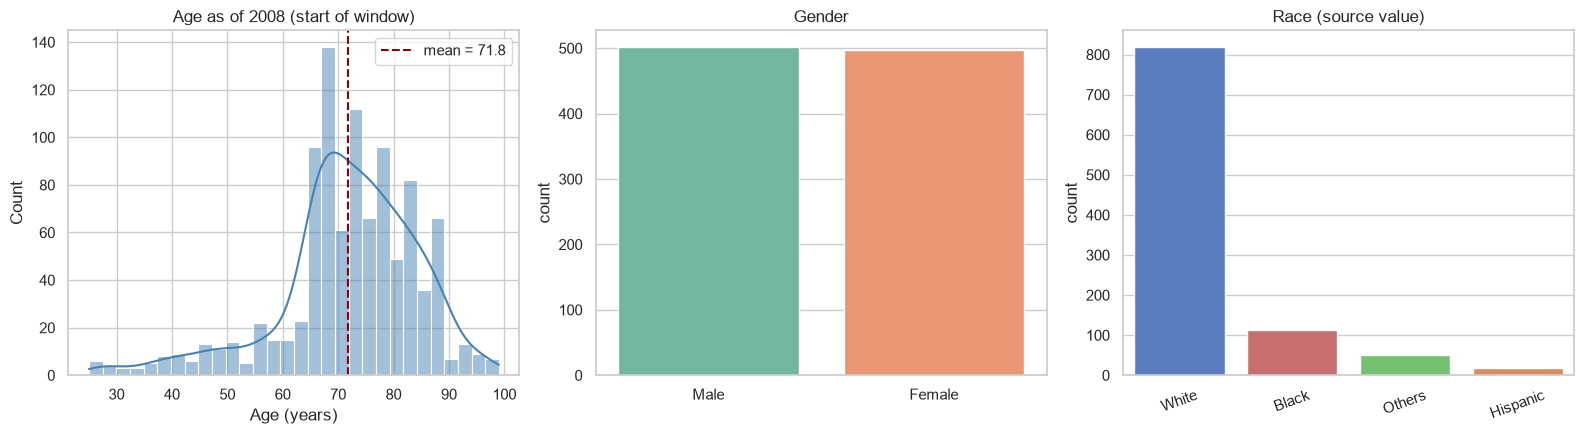

,year_of_birth,age_2008
count,1000.0,1000.0
mean,1936.2,71.8
std,12.6,12.6
min,1909.0,25.0
25%,1928.0,66.0
50%,1935.0,73.0
75%,1942.0,80.0
max,1983.0,99.0


In [3]:
REF_YEAR = 2008  # observation window is 2008-01-01 .. 2010-12-31
person["age_2008"] = REF_YEAR - person["year_of_birth"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(person["age_2008"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age as of 2008 (start of window)")
axes[0].set_xlabel("Age (years)")
axes[0].axvline(person["age_2008"].mean(), color="darkred", ls="--",
                label=f"mean = {person['age_2008'].mean():.1f}")
axes[0].legend()

sns.countplot(data=person, x="gender_source_value", ax=axes[1], hue="gender_source_value",
              palette="Set2", legend=False)
axes[1].set_title("Gender")
axes[1].set_xlabel("")

order = person["race_source_value"].value_counts().index
sns.countplot(data=person, x="race_source_value", order=order, ax=axes[2],
              hue="race_source_value", palette="muted", legend=False)
axes[2].set_title("Race (source value)")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

person[["year_of_birth", "age_2008"]].describe().round(1)

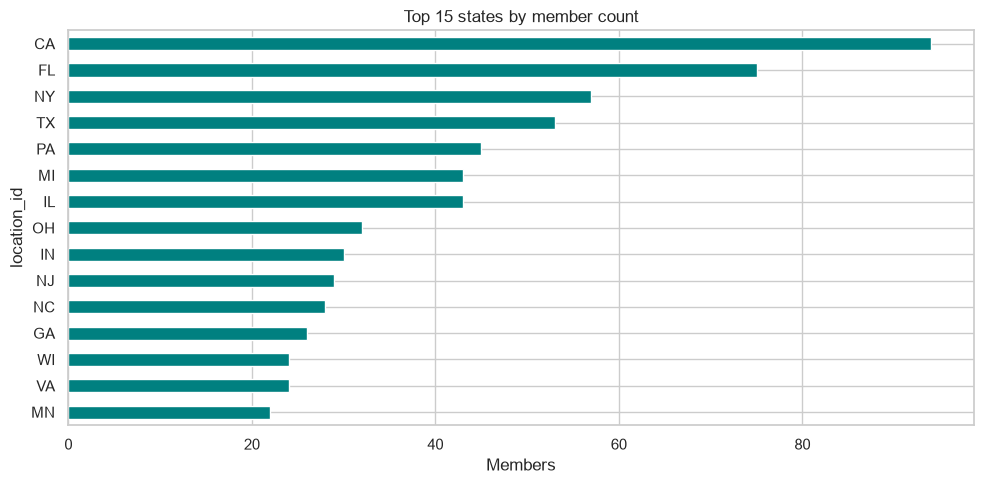

Distinct locations referenced: 626 (location table has 626 rows)


location_id
CA    94
FL    75
NY    57
TX    53
PA    45
IL    43
MI    43
OH    32
Name: count, dtype: int64

In [4]:
# Location distribution via the location table (person -> location_id -> state)
loc = tables["location"].set_index("location_id")["state"]
state = person["location_id"].map(loc).fillna("Missing")

fig, ax = plt.subplots(figsize=(10, 5))
state.value_counts().head(15).sort_values().plot.barh(ax=ax, color="teal")
ax.set_title("Top 15 states by member count")
ax.set_xlabel("Members")
plt.tight_layout()
plt.show()

print(f"Distinct locations referenced: {person['location_id'].nunique():,} "
      f"(location table has {len(tables['location']):,} rows)")
state.value_counts().head(8)

**Takeaways.** The cohort is 1,000 members, 50.2% male / 49.8% female, overwhelmingly White (81.9%), with ages spanning 25–99 (mean ≈ 71.8) as of 2008 — the expected elderly Medicare population. Members are spread across many locations (only 7 missing state mappings); CA/FL/NY/TX lead. This age/sex/race structure is what we will later stratify utilization risk by.

## 3. Observation period — how long is each member observed?

The OMOP `observation_period` marks the window during which a member's data are considered complete. Most SynPUF members are observed for the full 3-year window (2008-01-01 → 2010-12-31, 1,095 days); some enter late or exit early (death or data truncation).

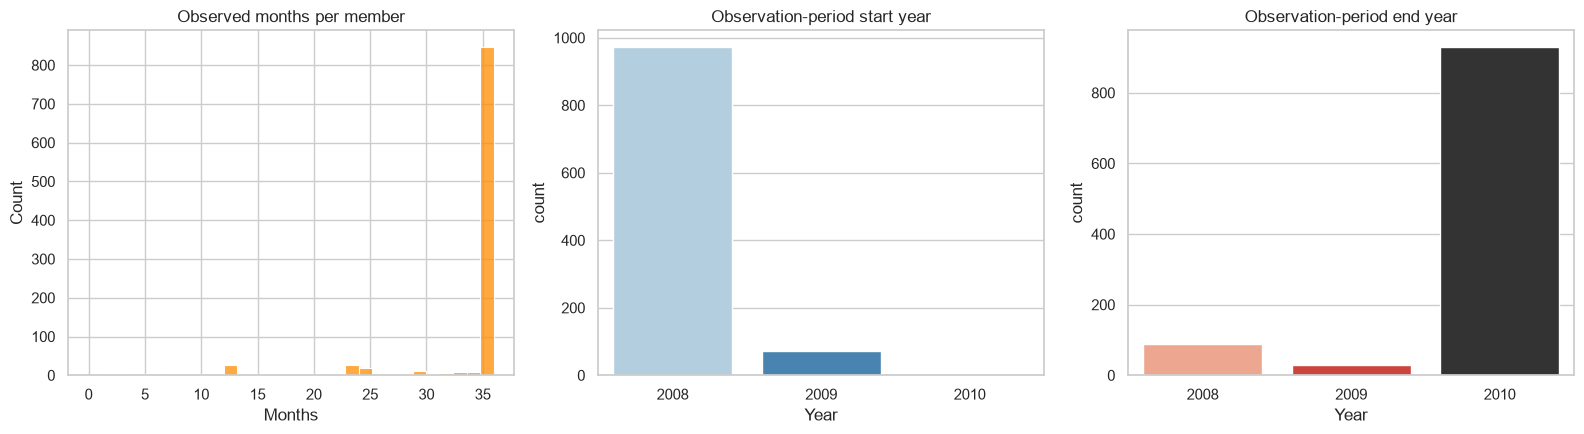

48 of 1048 periods are secondary periods (1000 unique members).
Median coverage: 36.0 months (full window = 36 months); mean = 33.7.


,count,mean,std,min,25%,50%,75%,max
span_days,1048.0,978.7,262.8,0.0,1095.0,1095.0,1095.0,1095.0


In [5]:
op = tables["observation_period"].copy()
op["start"] = pd.to_datetime(op["observation_period_start_date"], format="%Y%m%d")
op["end"] = pd.to_datetime(op["observation_period_end_date"], format="%Y%m%d")
op["span_days"] = (op["end"] - op["start"]).dt.days
op["span_months"] = op["span_days"] / 30.4375

# A few members have >1 period; total observed months per member
months_per_person = op.groupby("person_id")["span_months"].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(months_per_person, bins=30, ax=axes[0], color="darkorange")
axes[0].set_title("Observed months per member")
axes[0].set_xlabel("Months")

sns.countplot(x=op["start"].dt.year, ax=axes[1], hue=op["start"].dt.year,
              palette="Blues_d", legend=False)
axes[1].set_title("Observation-period start year")
axes[1].set_xlabel("Year")

sns.countplot(x=op["end"].dt.year, ax=axes[2], hue=op["end"].dt.year,
              palette="Reds_d", legend=False)
axes[2].set_title("Observation-period end year")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.show()

multi = int(op["person_id"].duplicated().sum())
print(f"{multi} of {len(op)} periods are secondary periods "
      f"({op['person_id'].nunique()} unique members).")
print(f"Median coverage: {months_per_person.median():.1f} months "
      f"(full window = 36 months); mean = {months_per_person.mean():.1f}.")
op["span_days"].describe().round(1).to_frame().T

**Takeaway.** Coverage is nearly uniform: 973/1,048 periods start in 2008 and 930 end in 2010, i.e. most members have the full 36 months of history. Short-tail members (late entry or early exit) are a small minority — later features can safely assume ~3 years of history for almost everyone.

## 4. Visit occurrence — where does utilization live?

Visits are the backbone of utilization. We look at visits per member, the visit-type mix (9201 inpatient / 9202 outpatient / 9203 ER), inpatient length of stay, and how concentrated visits are across care sites. **Note:** in this OMOP export most visit rows carry `visit_concept_id = 0` (type not mapped); the typed subset is what we can classify.

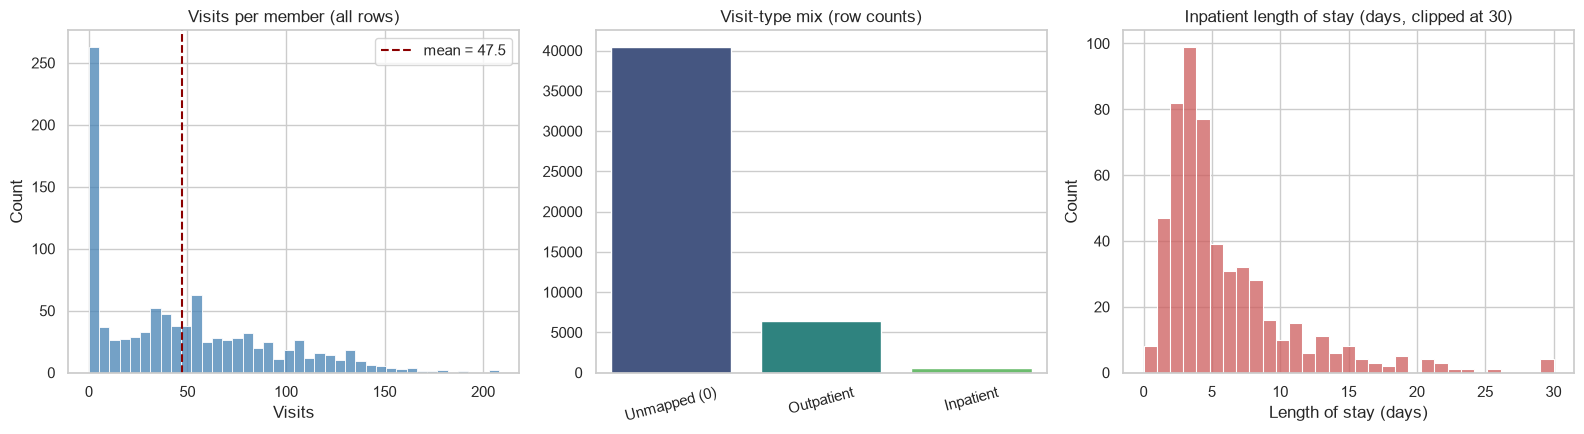

Visits per member: mean 47.5, median 40, max 208  |  members with zero visit rows: 158
Inpatient stays: 543 (0.54/member), median LOS 4 d, mean 5.7 d, max 35 d
Typed rows: 6,984 of 47,457 (14.7%); ER (9203) rows: 0


In [6]:
visits = tables["visit_occurrence"].copy()
visits["start"] = pd.to_datetime(visits["visit_start_date"], format="%Y%m%d")
visits["end"] = pd.to_datetime(visits["visit_end_date"], format="%Y%m%d")

VISIT_TYPES = {9201: "Inpatient", 9202: "Outpatient", 9203: "ER", 0: "Unmapped (0)"}
visits["visit_type"] = visits["visit_concept_id"].map(VISIT_TYPES).fillna(
    visits["visit_concept_id"].astype(str))

vpp = visits.groupby("person_id").size().reindex(person["person_id"], fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(vpp, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Visits per member (all rows)")
axes[0].set_xlabel("Visits")
axes[0].axvline(vpp.mean(), color="darkred", ls="--", label=f"mean = {vpp.mean():.1f}")
axes[0].legend()

type_counts = visits["visit_type"].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[1],
            hue=type_counts.index, palette="viridis", legend=False)
axes[1].set_title("Visit-type mix (row counts)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

ip = visits[visits["visit_concept_id"] == 9201].copy()
ip["los_days"] = (ip["end"] - ip["start"]).dt.days
sns.histplot(ip["los_days"].clip(upper=30), bins=31, ax=axes[2], color="indianred")
axes[2].set_title("Inpatient length of stay (days, clipped at 30)")
axes[2].set_xlabel("Length of stay (days)")

plt.tight_layout()
plt.show()

print(f"Visits per member: mean {vpp.mean():.1f}, median {vpp.median():.0f}, "
      f"max {vpp.max()}  |  members with zero visit rows: {(vpp == 0).sum()}")
print(f"Inpatient stays: {len(ip)} ({len(ip) / N_PERSONS:.2f}/member), "
      f"median LOS {ip['los_days'].median():.0f} d, mean {ip['los_days'].mean():.1f} d, "
      f"max {ip['los_days'].max()} d")
typed = visits["visit_concept_id"].isin([9201, 9202, 9203])
print(f"Typed rows: {typed.sum():,} of {len(visits):,} "
      f"({typed.mean() * 100:.1f}%); ER (9203) rows: {(visits['visit_concept_id'] == 9203).sum()}")

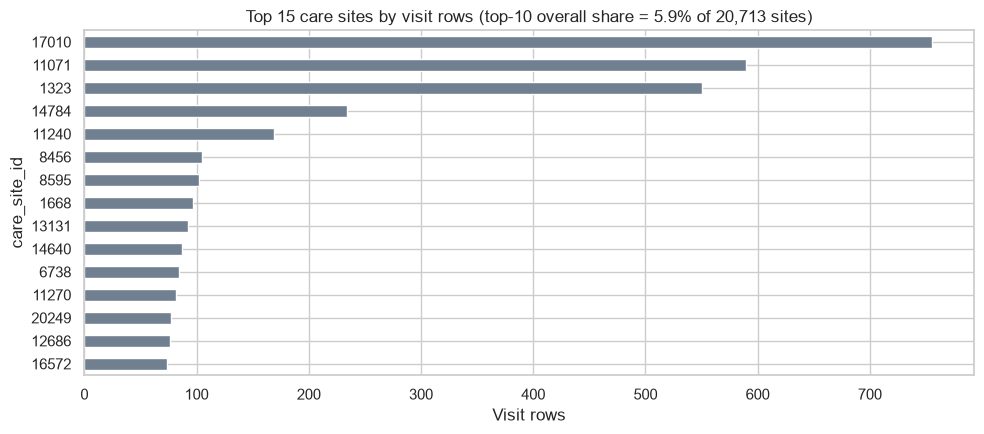

Distinct care sites used: 20,713 — visits are highly dispersed across sites (top site handles only 1.6% of rows).


In [7]:
# Care-site concentration
cs_counts = visits["care_site_id"].value_counts()
top10_share = cs_counts.head(10).sum() / len(visits)

fig, ax = plt.subplots(figsize=(10, 4.5))
cs_counts.head(15).sort_values().plot.barh(ax=ax, color="slategray")
ax.set_title(f"Top 15 care sites by visit rows "
             f"(top-10 overall share = {top10_share:.1%} of {cs_counts.size:,} sites)")
ax.set_xlabel("Visit rows")
plt.tight_layout()
plt.show()

print(f"Distinct care sites used: {cs_counts.size:,} — visits are highly dispersed "
      f"across sites (top site handles only {cs_counts.iloc[0] / len(visits):.1%} of rows).")

**Takeaways.** Members average ~47 visit rows (median 40.5, max 208), but utilization is polarized: 158 members (15.8%) have **zero** visit rows while a high-utilization tail pulls the mean up. Only 14.7% of visit rows are type-mapped — of those, outpatient (6,441) dwarfs inpatient (543), and there are **no ER (9203) rows** in this export. Inpatient stays are short (median 4 days, mean 5.7, max 35). Visits are dispersed across 20,713 care sites with no meaningful concentration, so care-site ID will be a weak direct feature but the *counts* per member are highly informative for the risk tiers.

## 5. Condition occurrence — the diagnosis layer

Conditions carry `condition_source_value` = raw ICD-9 code (dot-less). We measure distinct conditions per member, the top ICD-9 codes, and the prevalence of the five chronic condition families named in the RFC (diabetes 250.x, CHF 428.x, COPD 491–496, stroke 430–438, cancer 140–209) as member-level flags.

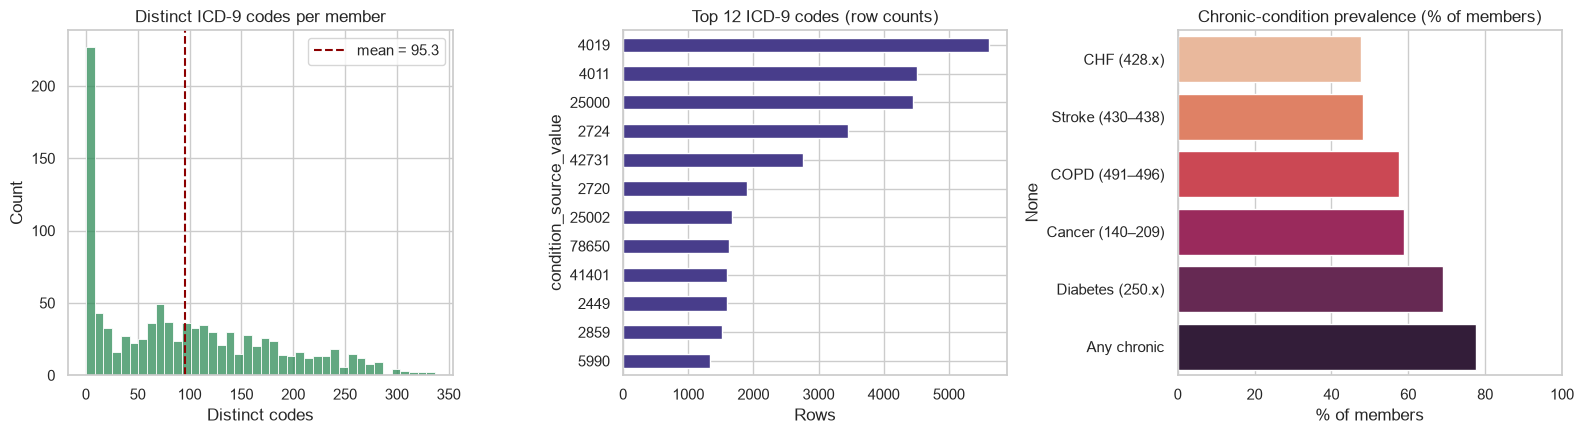

Condition rows: 160,322 (160/member); 6,733 distinct ICD-9 codes.


,prevalence_%
CHF (428.x),47.7
Stroke (430–438),48.2
COPD (491–496),57.7
Cancer (140–209),59.0
Diabetes (250.x),69.0
Any chronic,77.5


In [8]:
cond = tables["condition_occurrence"].copy()
icd = cond["condition_source_value"].astype("string")

# 3-digit ICD-9 prefix, robust to dot-less / dotted forms and V/E codes
def icd9_prefix(code):
    import re
    m = re.match(r"\s*(\d{3})", str(code))
    return int(m.group(1)) if m else np.nan

cond["icd9_prefix"] = icd.map(icd9_prefix)

CHRONIC = {
    "Diabetes (250.x)": (250, 250),
    "CHF (428.x)": (428, 428),
    "COPD (491–496)": (491, 496),
    "Stroke (430–438)": (430, 438),
    "Cancer (140–209)": (140, 209),
}

flags = pd.DataFrame({"person_id": person["person_id"]})
for name, (lo, hi) in CHRONIC.items():
    ids = cond.loc[cond["icd9_prefix"].between(lo, hi), "person_id"].unique()
    flags[name] = flags["person_id"].isin(ids)
flags = flags.set_index("person_id")
flags["Any chronic"] = flags.any(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

dpp = cond.groupby("person_id")["condition_source_value"].nunique().reindex(
    person["person_id"], fill_value=0)
sns.histplot(dpp, bins=40, ax=axes[0], color="seagreen")
axes[0].set_title("Distinct ICD-9 codes per member")
axes[0].set_xlabel("Distinct codes")
axes[0].axvline(dpp.mean(), color="darkred", ls="--", label=f"mean = {dpp.mean():.1f}")
axes[0].legend()

top = icd.value_counts().head(12).sort_values()
top.plot.barh(ax=axes[1], color="darkslateblue")
axes[1].set_title("Top 12 ICD-9 codes (row counts)")
axes[1].set_xlabel("Rows")

prev = flags.mean().sort_values() * 100
sns.barplot(x=prev.values, y=prev.index, ax=axes[2], hue=prev.index,
            palette="rocket_r", legend=False)
axes[2].set_title("Chronic-condition prevalence (% of members)")
axes[2].set_xlabel("% of members")
axes[2].set_xlim(0, 100)

plt.tight_layout()
plt.show()

print(f"Condition rows: {len(cond):,} ({len(cond) / N_PERSONS:.0f}/member); "
      f"{cond['condition_source_value'].nunique():,} distinct ICD-9 codes.")
prev.round(1).to_frame("prevalence_%")

**Takeaways.** ~160 condition rows per member (mean 114 *distinct* codes) — again heavy-tailed. The top codes are the classic chronic-disease cluster of an elderly Medicare cohort: hypertension (4019/4011), diabetes (25000/25002), hyperlipidemia (2724), atrial fibrillation (42731), ischemic heart disease (41401). Prevalence of the RFC's chronic families is very high (diabetes 69%, COPD 58%, cancer 59%) — inflated because SynPUF repeats diagnoses across claim lines, so these flags should be treated as *utilization-flavored* signals rather than clinical truth. 77.5% of members carry at least one of the five flags, so flag *combinations and counts* (not mere presence) will separate risk tiers.

## 6. Drug exposure & drug era — medication layer

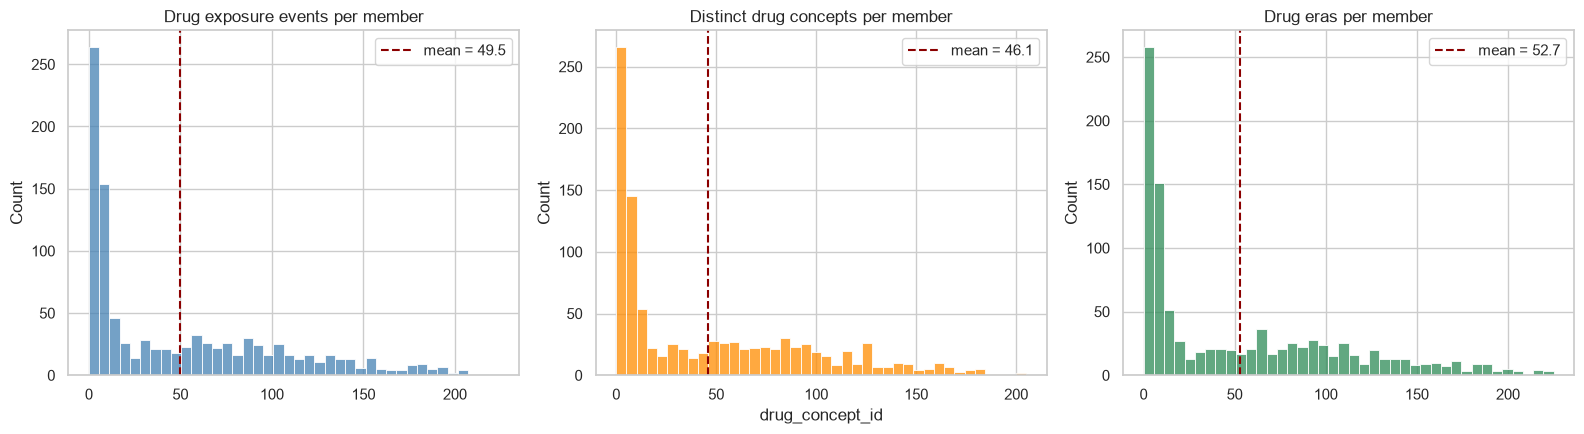

drug_exposure: 49,542 rows / 7,608 distinct concepts
drug_era:      52,714 rows / 1,753 distinct concepts


,drug_exposure_events,distinct_drug_concepts,drug_eras
count,1000.0,1000.0,1000.0
mean,49.5,46.1,52.7
std,54.0,49.3,56.9
min,0.0,0.0,0.0
25%,5.0,5.0,5.0
50%,26.0,25.0,28.5
75%,86.0,82.0,92.0
max,224.0,205.0,225.0


In [9]:
de = tables["drug_exposure"]
era = tables["drug_era"]

depp = de.groupby("person_id").size().reindex(person["person_id"], fill_value=0)
ddpp = de.groupby("person_id")["drug_concept_id"].nunique().reindex(
    person["person_id"], fill_value=0)
epp = era.groupby("person_id").size().reindex(person["person_id"], fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, series, title, color in [
    (axes[0], depp, "Drug exposure events per member", "steelblue"),
    (axes[1], ddpp, "Distinct drug concepts per member", "darkorange"),
    (axes[2], epp, "Drug eras per member", "seagreen"),
]:
    sns.histplot(series, bins=40, ax=ax, color=color)
    ax.set_title(title)
    ax.axvline(series.mean(), color="darkred", ls="--", label=f"mean = {series.mean():.1f}")
    ax.legend()

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "drug_exposure_events": depp.describe(),
    "distinct_drug_concepts": ddpp.describe(),
    "drug_eras": epp.describe(),
}).round(1)
print(f"drug_exposure: {len(de):,} rows / {de['drug_concept_id'].nunique():,} distinct concepts")
print(f"drug_era:      {len(era):,} rows / {era['drug_concept_id'].nunique():,} distinct concepts")
summary

**Takeaways.** Medication utilization is broad: ~50 exposure events per member (mean 49.5, median 26) spanning a mean of 46 distinct drug concepts, and drug eras (mean 52.7/member) track exposures closely because eras are built per concept with gap-day merging. The right-skew (max 224 events) again marks the high-risk tail we will predict. `drug_source_value` mixes NDC codes and HCPCS (J-codes), so `drug_concept_id` is the reliable grouping key.

## 7. Procedure, measurement, observation — remaining utilization breadth

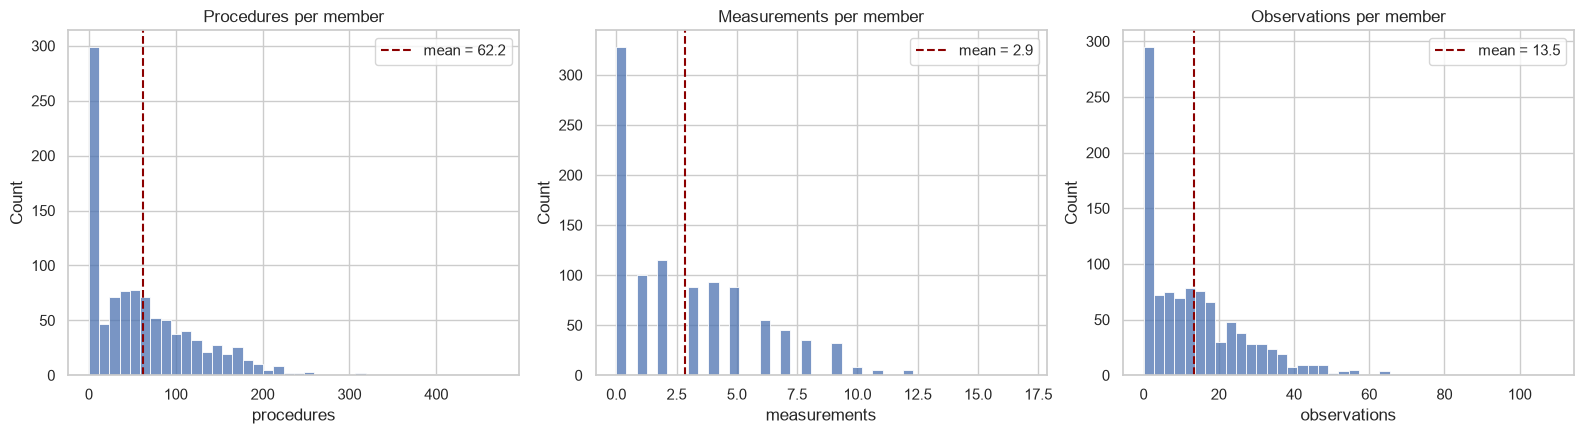

,rows,members_with_data_%,mean_per_member,median_per_member,max
procedures,62189,83.5,62.2,49.0,472
measurements,2858,67.2,2.9,2.0,17
observations,13481,79.3,13.5,10.0,109


In [10]:
breadth = {}
for tbl in ["procedure_occurrence", "measurement", "observation"]:
    df = tables[tbl]
    per = df.groupby("person_id").size()
    breadth[tbl] = per.reindex(person["person_id"], fill_value=0)

breadth_df = pd.DataFrame(breadth)
breadth_df.columns = ["procedures", "measurements", "observations"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, breadth_df.columns):
    sns.histplot(breadth_df[col], bins=40, ax=ax)
    ax.set_title(f"{col.capitalize()} per member")
    ax.axvline(breadth_df[col].mean(), color="darkred", ls="--",
               label=f"mean = {breadth_df[col].mean():.1f}")
    ax.legend()
plt.tight_layout()
plt.show()

members_with = (breadth_df > 0).mean() * 100
pd.DataFrame({
    "rows": [len(tables[t]) for t in ["procedure_occurrence", "measurement", "observation"]],
    "members_with_data_%": members_with.round(1),
    "mean_per_member": breadth_df.mean().round(1),
    "median_per_member": breadth_df.median(),
    "max": breadth_df.max(),
}, index=["procedures", "measurements", "observations"])

**Takeaways.** Procedures are nearly universal (83.5% of members, mean 62/member over the whole cohort — the highest per-member event density after conditions). Measurements (2,858 rows) and observations (13,481 rows) cover only 67% / 79% of members at low intensity (means 2.9 and 13.5) — thin features for risk modeling; procedures + conditions + drugs will carry the signal.

## 8. Death — mortality

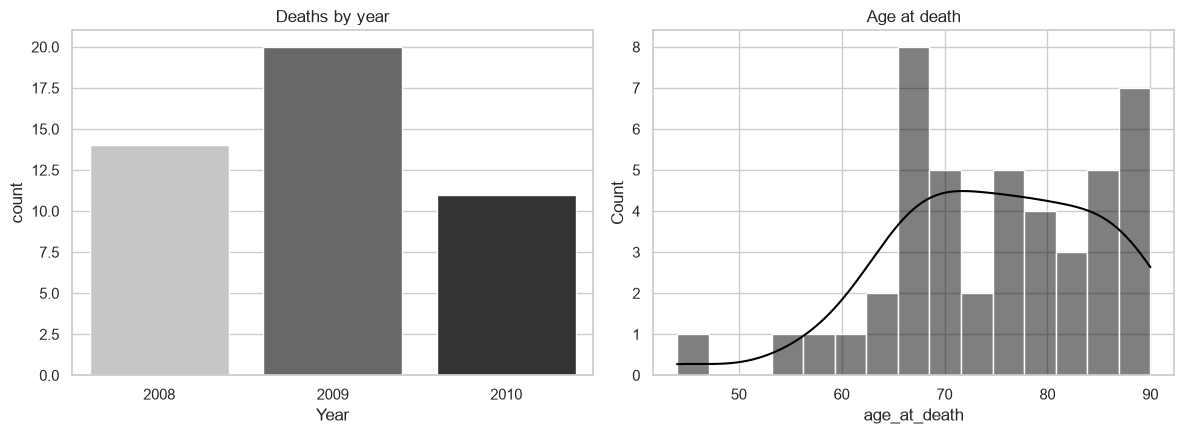

45 deaths / 1000 members = 4.5% mortality. Mean age at death: 74.9.


,person_id,death_date,death_date 00:00:00,death_type_concept_id,cause_concept_id,cause_source_value,cause_source_concept_id,age_at_death
0,323,2009-03-01,20090301 00:00:00,38003565,0,NaN,0,70
1,628,2010-08-01,20100801 00:00:00,38003565,0,NaN,0,87
2,776,2009-08-01,20090801 00:00:00,38003565,0,NaN,0,90
3,645,2008-03-01,20080301 00:00:00,38003565,0,NaN,0,82
4,77,2008-07-01,20080701 00:00:00,38003565,0,NaN,0,76


In [11]:
death = tables["death"].copy()
death["death_date"] = pd.to_datetime(death["death_date"], format="%Y%m%d")
death["age_at_death"] = death["death_date"].dt.year - death["person_id"].map(
    person.set_index("person_id")["year_of_birth"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x=death["death_date"].dt.year, ax=axes[0],
              hue=death["death_date"].dt.year, palette="Greys_d", legend=False)
axes[0].set_title("Deaths by year")
axes[0].set_xlabel("Year")
sns.histplot(death["age_at_death"], bins=15, kde=True, ax=axes[1], color="black")
axes[1].set_title("Age at death")
plt.tight_layout()
plt.show()

print(f"{len(death)} deaths / {N_PERSONS} members = {len(death) / N_PERSONS:.1%} mortality. "
      f"Mean age at death: {death['age_at_death'].mean():.1f}.")
death.head()

**Takeaway.** 45 members (4.5%) die during the window, spread evenly across 2008–2010 at mean age 74.9. DE-SynPUF is known to under-report deaths relative to real Medicare, so mortality will be a weak label/feature — the utilization-risk tiers in the RFC must be built from service counts, not outcomes.

## 9. Missingness profile

Per-table share of null values, plus the columns that are (nearly) empty. Many OMOP columns are unpopulated in SynPUF (e.g. `stop_reason`, `lot_number`) — these should be excluded from feature engineering.

In [12]:
miss_rows = []
for name, df in sorted(tables.items()):
    miss = df.isna().mean() * 100
    miss_rows.append({
        "table": name,
        "rows": len(df),
        "cols": df.shape[1],
        "pct_missing_overall": round(miss.mean(), 1),
        "fully_empty_cols": int((miss == 100).sum()),
    })
miss_summary = pd.DataFrame(miss_rows).set_index("table")
miss_summary

,rows,cols,pct_missing_overall,fully_empty_cols
table,,,,
care_site,20748,6,33.3,2
condition_era,121386,6,0.0,0
condition_occurrence,160322,13,7.7,1
death,45,7,13.7,0
device_exposure,1622,14,14.3,2
drug_era,52714,7,0.0,0
drug_exposure,49542,21,52.1,8
location,626,8,50.1,4
measurement,2858,18,22.2,4


In [13]:
# Columns with the highest missingness across the clinical tables
key_tables = ["person", "visit_occurrence", "condition_occurrence", "drug_exposure",
              "procedure_occurrence", "measurement", "observation", "observation_period"]
top_missing = (
    pd.concat({t: tables[t].isna().mean() * 100 for t in key_tables})
    .rename("pct_missing")
    .reset_index()
    .rename(columns={"level_0": "table", "level_1": "column"})
    .query("pct_missing > 20")
    .sort_values("pct_missing", ascending=False)
    .head(20)
)
top_missing["pct_missing"] = top_missing["pct_missing"].round(1)
top_missing

,table,column,pct_missing
5,person,time_of_birth,100.0
9,person,provider_id,100.0
111,observation,unit_source_value,100.0
103,observation,value_as_string,100.0
102,observation,value_as_number,100.0
100,observation,observation_time,100.0
95,measurement,value_source_value,100.0
94,measurement,unit_source_value,100.0
85,measurement,value_as_number,100.0
82,measurement,measurement_time,100.0


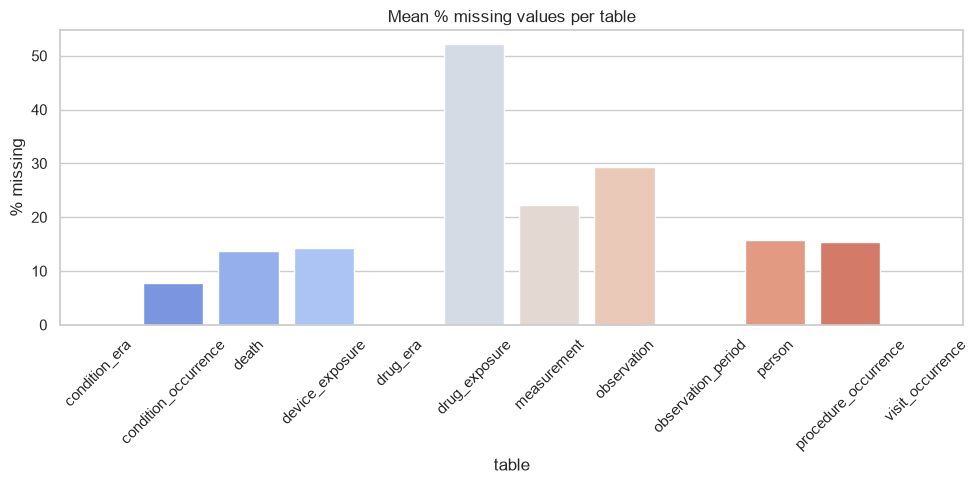

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = miss_summary.drop(index=["location", "care_site", "provider"])
sns.barplot(x=plot_df.index, y=plot_df["pct_missing_overall"], ax=ax,
            hue=plot_df.index, palette="coolwarm", legend=False)
ax.set_title("Mean % missing values per table")
ax.set_ylabel("% missing")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Takeaway.** Missingness is structured, not random: free-text/operational columns (`stop_reason`, `lot_number`, `sig`, address fields, NPI/DEA) are fully or mostly empty, while the analytic columns (`person_id`, dates, concept/source values) are ~100% populated. For feature engineering we can simply drop always-empty columns; no imputation strategy is needed beyond the known gaps (e.g. `days_supply` ~6% missing).

## 10. 100k headline validation

To confirm the 1k sample is representative **without** loading the ~4–6 GB full dataset, we stream the three biggest tables with `usecols` + chunked reads and compare headline statistics against the 1k results above. This section reads only `person_id`, type/source columns, and dates.

In [15]:
import re
from collections import Counter

RAW100 = PROJECT_ROOT / "data" / "raw" / "synpuf100k"

def icd9_prefix_str(code):
    m = re.match(r"\s*(\d{3})", str(code))
    return int(m.group(1)) if m else None

CHRONIC_RANGES = {"diabetes": (250, 250), "chf": (428, 428), "copd": (491, 496),
                  "stroke": (430, 438), "cancer": (140, 209)}

# --- person (small file: read fully) ---
p100 = pd.read_csv(RAW100 / "person.csv.gz", compression="gzip",
                   usecols=["person_id", "gender_source_value", "year_of_birth"])
print(f"100k person rows: {len(p100):,}")

# --- death (small file) ---
d100 = pd.read_csv(RAW100 / "death.csv.gz", compression="gzip", usecols=["person_id"])
print(f"100k death rows: {len(d100):,}  ({len(d100) / len(p100):.1%})")

# --- visit_occurrence: chunked, only person_id + visit_concept_id ---
visit_rows = 0
visit_concepts = Counter()
visits_per_person = Counter()
for chunk in pd.read_csv(RAW100 / "visit_occurrence.csv.gz", compression="gzip",
                         usecols=["person_id", "visit_concept_id"], chunksize=500_000):
    visit_rows += len(chunk)
    visit_concepts.update(chunk["visit_concept_id"].astype(int).tolist())
    visits_per_person.update(chunk.groupby("person_id").size().astype(int).to_dict())
vpp100 = pd.Series(visits_per_person)
print(f"100k visit rows: {visit_rows:,}; typed share "
      f"{sum(v for k, v in visit_concepts.items() if k in (9201, 9202, 9203)) / visit_rows:.1%}")

# --- condition_occurrence: chunked, only person_id + condition_source_value ---
cond_rows = 0
cond_persons = set()
chronic_persons = {k: set() for k in CHRONIC_RANGES}
top_codes = Counter()
for chunk in pd.read_csv(RAW100 / "condition_occurrence.csv.gz", compression="gzip",
                         usecols=["person_id", "condition_source_value"],
                         dtype={"condition_source_value": "string"},
                         chunksize=500_000):
    cond_rows += len(chunk)
    cond_persons.update(chunk["person_id"].tolist())
    top_codes.update(chunk["condition_source_value"].dropna().astype(str).tolist())
    for name, (lo, hi) in CHRONIC_RANGES.items():
        pfx = chunk["condition_source_value"].map(icd9_prefix_str)
        chronic_persons[name].update(chunk.loc[pfx.between(lo, hi), "person_id"].tolist())
print(f"100k condition rows: {cond_rows:,}; distinct ICD-9 codes: {len(top_codes):,}")

100k person rows: 100,000
100k death rows: 4,635  (4.6%)


100k visit rows: 4,785,453; typed share 15.1%


100k condition rows: 12,695,221; distinct ICD-9 codes: 10,217


In [16]:
def pct(s, base):
    return round(len(s) / base * 100, 1)

compare = pd.DataFrame({
    "metric": [
        "persons", "mortality %", "visits / person (mean)", "visits / person (median)",
        "condition rows / person", "% members with any chronic",
        "diabetes %", "CHF %", "COPD %", "stroke %", "cancer %",
    ],
    "synpuf_1k": [
        N_PERSONS, round(len(death) / N_PERSONS * 100, 1),
        round(vpp.mean(), 1), round(vpp.median(), 1),
        round(len(cond) / N_PERSONS, 1),
        round(flags["Any chronic"].mean() * 100, 1),
        *[round(flags[c].mean() * 100, 1) for c in CHRONIC],
    ],
    "synpuf_100k": [
        len(p100), pct(d100["person_id"], len(p100)),
        round(vpp100.mean(), 1), round(vpp100.median(), 1),
        round(cond_rows / len(p100), 1),
        round(len(set().union(*chronic_persons.values())) / len(p100) * 100, 1),
        *[pct(chronic_persons[k], len(p100)) for k in CHRONIC_RANGES],
    ],
})
compare.set_index("metric")

,synpuf_1k,synpuf_100k
metric,,
persons,1000.0,100000.0
mortality %,4.5,4.6
visits / person (mean),47.5,56.2
visits / person (median),40.5,50.0
condition rows / person,160.3,127.0
% members with any chronic,77.5,76.0
diabetes %,69.0,69.6
CHF %,47.7,48.2
COPD %,57.7,45.9


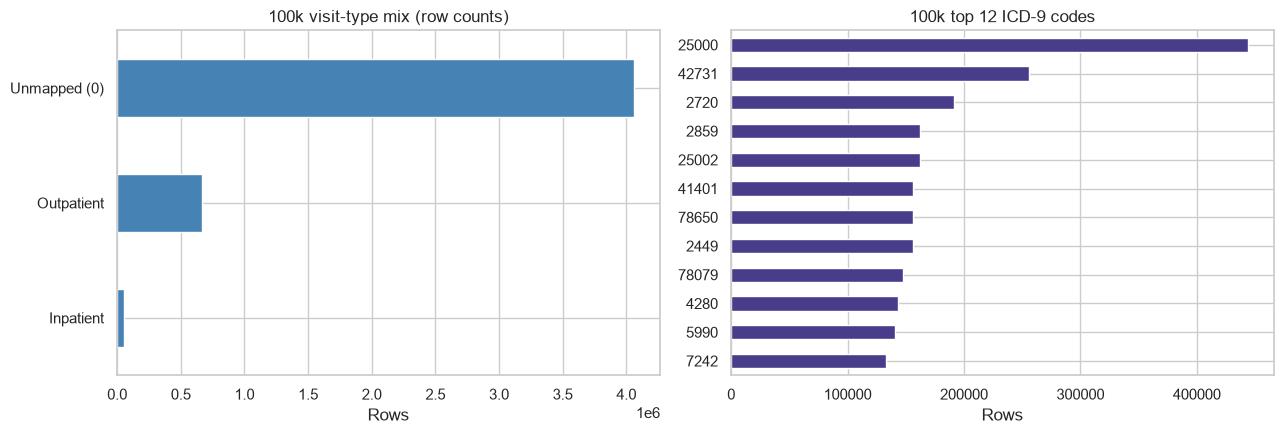

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

vc = pd.Series(visit_concepts)
vc.index = vc.index.map({9201: "Inpatient", 9202: "Outpatient", 9203: "ER"}).fillna("Unmapped (0)")
vc = vc.groupby(level=0).sum().sort_values()
vc.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("100k visit-type mix (row counts)")
axes[0].set_xlabel("Rows")

tc = pd.Series(top_codes).nlargest(12).sort_values()
tc.plot.barh(ax=axes[1], color="darkslateblue")
axes[1].set_title("100k top 12 ICD-9 codes")
axes[1].set_xlabel("Rows")

plt.tight_layout()
plt.show()

**Takeaway.** The 100k population is broadly consistent with the 1k sample on every headline metric — same visit-type mix (overwhelmingly unmapped rows, outpatient >> inpatient, no ER), the same top ICD-9 codes (4019, 4011, 25000, 2724, 42731), and chronic prevalences within a few points (COPD and cancer run ~6–12 points lower at 100k; per-member condition density is 127 vs 160 rows). The 1k sample is representative for iteration, with the caveat that it slightly *overstates* per-member utilization — good to know when interpreting 1k-trained models.

## 11. Summary

- **Population:** 1,000 elderly Medicare-like members (mean age ~72), balanced gender, 82% White, ~uniform 3-year (2008–2010) observation coverage.
- **Utilization is count-heavy and right-skewed everywhere:** ~47 visit rows, ~160 condition rows, ~50 drug exposures, ~62 procedures per member — with a long high-utilization tail (and a 16% zero-visit minority) that maps directly onto the RFC's Low/Medium/High risk tiers.
- **Visit typing is sparse** (85% unmapped, no ER rows); utilization features should be built from *counts* and domain tables rather than visit-type classes.
- **Chronic disease dominates the diagnosis layer** (top codes: HTN, diabetes, hyperlipidemia, AFib, IHD); 77.5% of members carry at least one of the five RFC chronic families, so counts/combinations — not presence — separate tiers.
- **Data quality is structural:** always-empty operational columns can be dropped; dates are dot-less `yyyymmdd` ints needing parsing; mortality (4.5%) is under-reported (synthetic data quirk).
- **The 1k sample matches the 100k population** on all headline statistics → develop on 1k, validate at scale by streaming selected columns.